# **Explainable Diabetes Prediction**

Author: Zohreh Kazemi

# **Introduction**

---

Diabetes is a disease that affects how the body controls sugar in the blood. It is one of the most common health problems in the world today and affects millions of people. If not treated early, diabetes can cause serious problems like heart disease, kidney damage, and blindness. The number of people with diabetes is increasing because of unhealthy food habits, lack of exercise, and obesity. In this project, the Pima Indians Diabetes Dataset is analyzed to predict diabetes.

The Pima Indians Diabetes Dataset is a medical dataset used to predict whether a patient has diabetes based on different health measurements. The dataset contains 768 patient records and 9 columns, where the first 8 columns are input features and the last column, Outcome, shows whether the patient has diabetes (1) or not (0). The features include important medical information such as number of pregnancies, glucose level, blood pressure, skin thickness, insulin level, BMI, diabetes pedigree function, and age. This dataset is widely used in data science and machine learning projects for classification and prediction tasks.

This project develops interpretable machine learning models for diabetes prediction using the Pima Indians Diabetes dataset. Decision Tree and Random Forest classifiers were trained and evaluated using cross-validation, followed by PCA-based visualization and interpretation.

# **Exploratory Data Analysis**

In [ ]:
#importing the necessary libraries and packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, recall_score, precision_score, roc_curve, roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.decomposition import PCA



In [ ]:
import pandas as pd

url = "https://gist.githubusercontent.com/dmpe/bfe07a29c7fc1e3a70d0522956d8e4a9/raw/pima-indians-diabetes.csv"

# Load dataset directly from raw URL
data = pd.read_csv(url, header = None)

data.columns = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
              'Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']

# Show first few rows
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# Size of dataset
data.shape

(768, 9)

In [ ]:
# Summary stats
data.describe(include='all')

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


`data.shape` shows that the dataset contains information for 768 patients. By comparing this with the `count` values in the summary table, we can see that there are no missing values recorded. Looking at the `min` values, all features are non-negative, which is expected for physiological data. However, the `min` row also shows that some columns, such as Glucose, Blood Pressure, Skin Thickness, Insulin, and BMI, contain zero values. These values are not realistic, since these measurements cannot be zero in a living person. Therefore, these zero entries are treated as missing values and need to be handled before building the model.

In [ ]:
#Look out for any missing values in any of the columns
data.isna().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
columns_with_zeros = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

# Count zeros in these columns
(data[columns_with_zeros] == 0).sum()

,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


In [ ]:
# replace zeros in these columns by nan
data[columns_with_zeros] = data[columns_with_zeros].replace(0, np.nan)

# Show % of missing values
(data.isna().sum() / len(data)) * 100

,0
Pregnancies,0.000000
Glucose,0.651042
BloodPressure,4.557292
SkinThickness,29.557292
Insulin,48.697917
BMI,1.432292
DiabetesPedigreeFunction,0.000000
Age,0.000000
Outcome,0.000000


All missing value were replaced by median. Median imputation was chosen because features like Glucose and BMI contain outliers, making the mean less reliable. Outliers were identified by looking at the median, maximum values, and standard deviation. A large difference between typical and extreme values, especially in Insulin and BMI, suggests the presence of outliers.

Following plots visualize the the presence of outliers.

In [ ]:
# Define a theme to keep consistency for all plot
def set_custom_theme():
    sns.set_theme(style="whitegrid")

    plt.rcParams.update({
        # Figure & axes
        "figure.figsize": (8, 5),
        "figure.facecolor": "#FCF9F3",
        "axes.facecolor": "#F1EBDA",
        "axes.edgecolor": "#4A4431",

        # Text
        "axes.labelcolor": "black",
        "text.color": "black",
        "font.size": 14,
        "axes.titleweight": "bold",
        "axes.labelweight": "bold",

        # Grid
        "grid.color": "#4A443199",
        "grid.linewidth": 0.2,

        # Ticks
        "xtick.color": "black",
        "ytick.color": "black",

        # Legend
        "legend.frameon": True
    })
set_custom_theme()

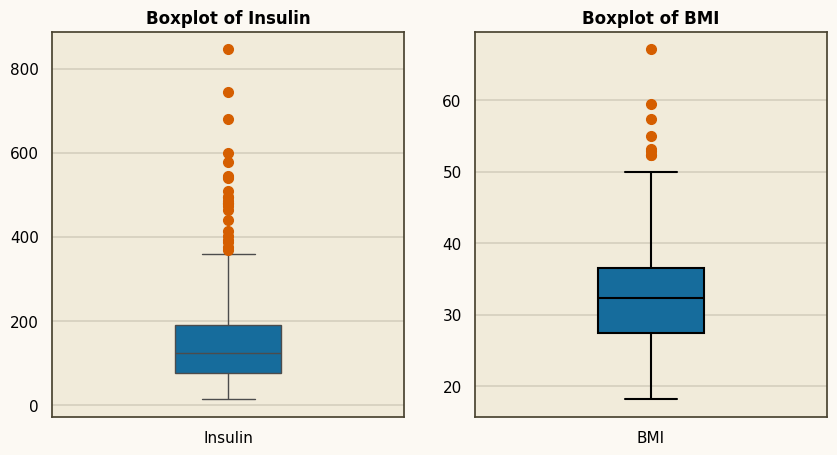

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))

sns.boxplot(
    data = data[['Insulin']],
    ax=axes[0],
    width = 0.3,  color = "#0072B2", # controls box width
    flierprops = dict(  # controls outliers
        marker ='o',
        markerfacecolor = '#D55E00',   # filled color
        markeredgecolor = '#D55E00',
        markersize = 7
    )
)
axes[0].set_title("Boxplot of Insulin")

sns.boxplot(
    data = data[['BMI']],
    ax=axes[1],
    width = 0.3,  color = "#0072B2",
    # Box edge (outline)
    boxprops=dict(edgecolor='black', linewidth=1.5),

    # Whiskers (lines extending from box)
    whiskerprops=dict(color='black', linewidth=1.5),

    # Caps (horizontal lines at ends)
    capprops=dict(color='black', linewidth=1.5),

    # Median line inside box
    medianprops=dict(color='black', linewidth=1.5),

    flierprops = dict(  # controls outliers
        marker ='o',
        markerfacecolor = '#D55E00',   # filled color
        markeredgecolor = '#D55E00',
        markersize = 7
    )
)
axes[1].set_title("Boxplot of BMI")

plt.show()

In [ ]:
data.fillna(data.median(), inplace=True)

# Make sure there is no missing value
data.isna().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
data.describe(include='all')


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Histograms were used to examine the distribution of the numerical features. These plots help identify patterns such as skewness, outliers, differences in spread, and potential subgroup structures. Understanding feature distributions is important for detecting possible preprocessing needs such as transformation, outlier handling, or scaling.

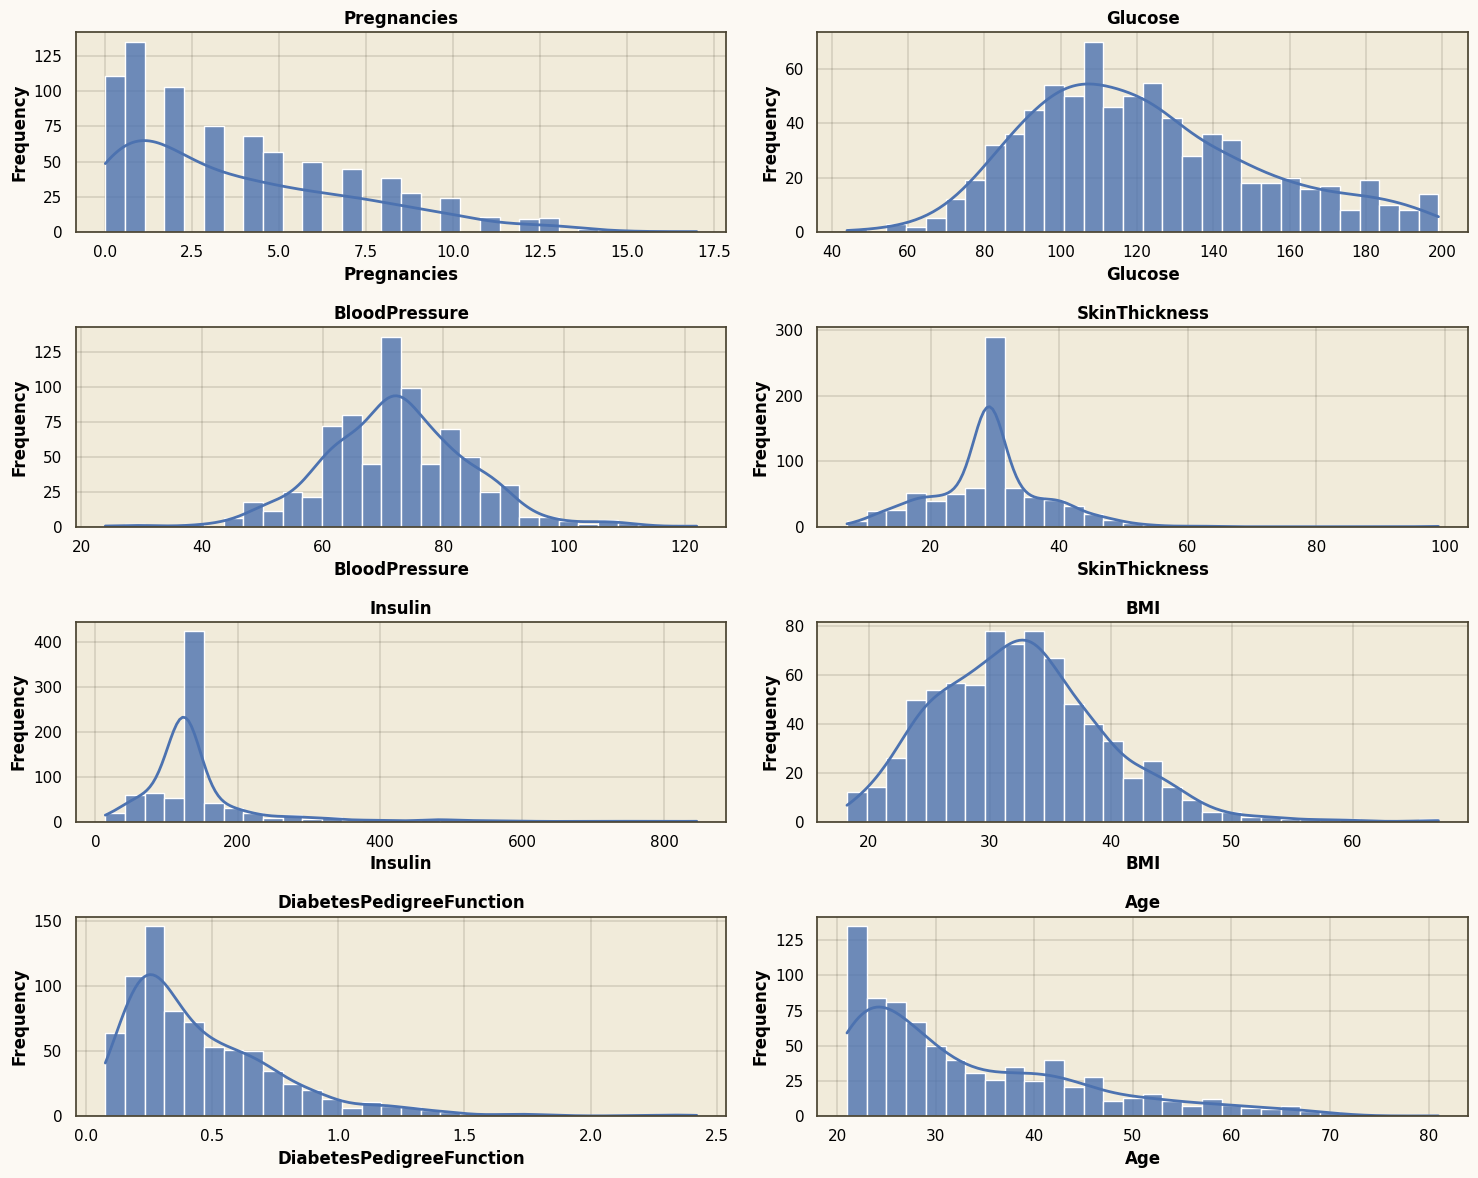

In [ ]:
#Checking the distribution of each numeric columns
numerical_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                     'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(4, 2, figsize=(15, 12))
axes = axes.ravel()

# for i, col in enumerate(numerical_cols):
#         axes[i].hist(data[col], bins=30, alpha=0.7,)
#         axes[i].set_title(f'{col}')
#         axes[i].set_xlabel(col)
#         axes[i].set_ylabel('Frequency')
# plt.tight_layout()
# plt.show()

for i, col in enumerate(numerical_cols):
    sns.histplot(data[col], bins=30, kde=True, ax=axes[i], line_kws={'linewidth': 2}, alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


After looking at the distributions, not all features need the same treatment. Blood Pressure, BMI, and Glucose have fairly normal distributions, so no transformation is needed. Pregnancies is slightly skewed, but since it represents count data, it is left unchanged. Skin Thickness has some skewness but is still acceptable without changes. Insulin and Diabetes Pedigree Function are highly skewed with extreme values, so a log transformation is applied to make them more balanced. Age is also slightly skewed, but it is kept unchanged because the distribution reflects real-world patterns and remains easy to interpret.

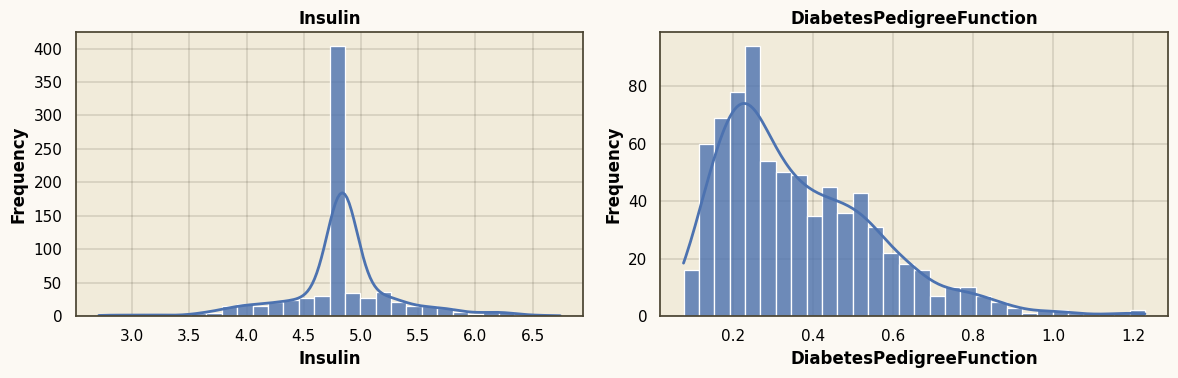

In [ ]:
data['DiabetesPedigreeFunction'] = np.log1p(data['DiabetesPedigreeFunction'])
data['Insulin'] = np.log1p(data['Insulin'])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes = axes.ravel()
for i, col in enumerate(['Insulin', 'DiabetesPedigreeFunction']):
    sns.histplot(data[col], bins=30, kde=True, ax=axes[i], line_kws={'linewidth': 2}, alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

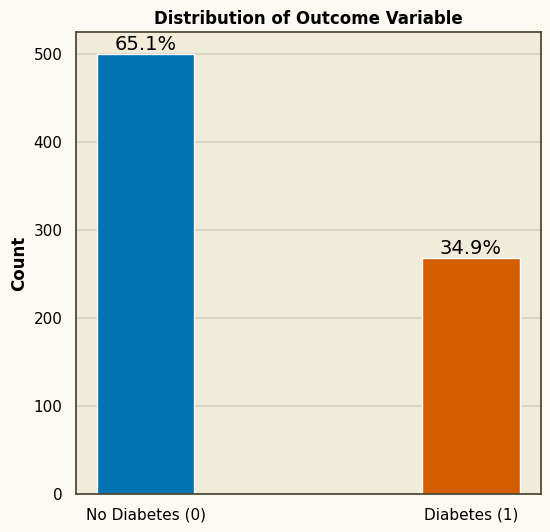

In [ ]:
#Lets evaluate the class distribution of the Outcome variable and determine the degree of class imabalance if exist
data['Outcome'].value_counts()

print("\n")
outcome_counts = data['Outcome'].value_counts().sort_index()
plt.figure(figsize=(6, 6))
plt.bar(['No Diabetes (0)', 'Diabetes (1)'], outcome_counts.values, color=['#0072B2', '#D55E00'], width=0.3)

# Remove vertical gridlines
plt.grid(axis='x', visible=False)

for i, v in enumerate(outcome_counts.values):
    percent = (v / data.shape[0]) * 100
    plt.text(i, v + 5, f'{percent:.1f}%', ha='center') # Place percentage text slightly above each bar (x = bar index, y = height + offset)

plt.title('Distribution of Outcome Variable')
plt.ylabel('Count')
plt.show()

Due to the presence of class imbalance in the target variable, stratified sampling was used during the train-test split to ensure that both training and testing datasets maintain the same class distribution as the original dataset. This helps produce more reliable and unbiased model evaluation.

Highly correlated features are pairs or groups of input variables whose values move together so strongly that they carry nearly the same information. The correlation can be positive (both increase/decrease together) or negative (one increases as the other decreases); what matters is the magnitude of the relationship. We typically measure this with the Pearson correlation coefficient, which ranges from −1 to +1. Values near the extremes (e.g., magnitude of 0.8–0.9) indicate strong correlation, while values near 0 indicate little linear correlation (not necessarily independence). When a set of features is highly correlated, you can often keep one and drop or combine the others to reduce redundancy and simplify the model.

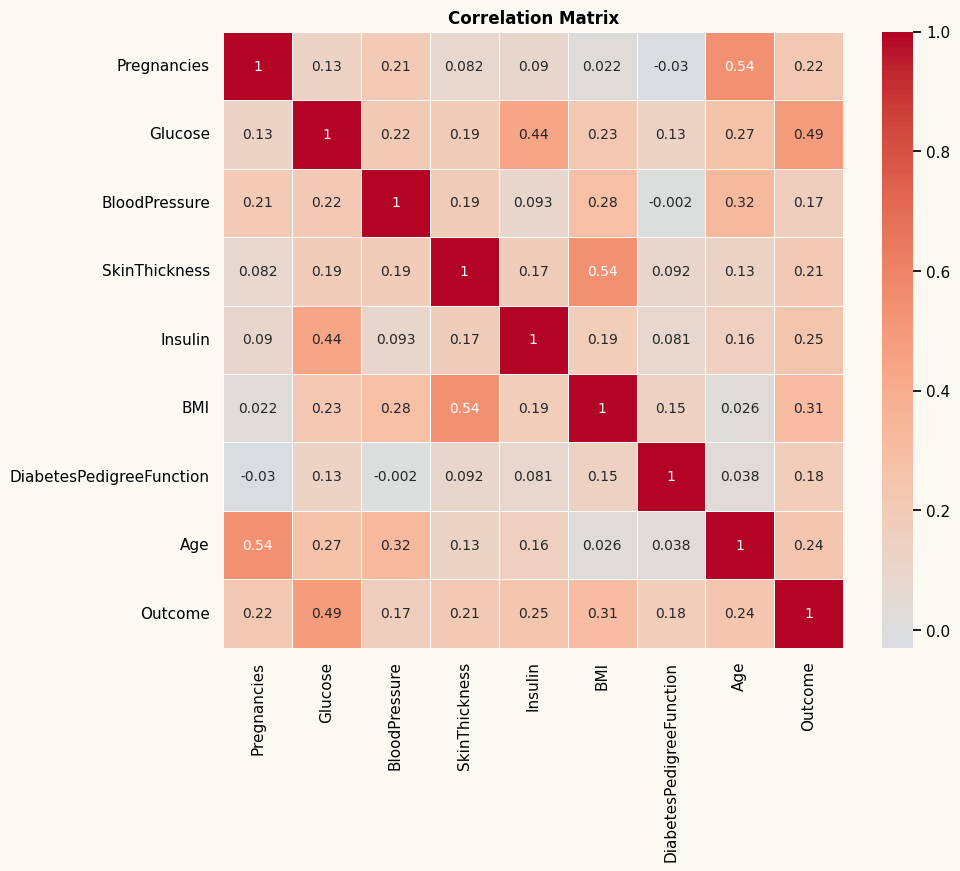

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', center=0, annot_kws={"size": 10}, linewidths=0.7)
plt.title('Correlation Matrix')
plt.show()

The correlation matrix shows that most feature relationships are weak to moderate, with no values exceeding 0.8. This means there is no serious multicollinearity in the dataset. While some moderate correlations exist (e.g., BMI and Skin Thickness, Age and Pregnancies), they are not strong enough to remove any features. Therefore, all features were kept for modeling. Additionally, Glucose shows the highest correlation with the target variable, suggesting it may be an important predictor of diabetes.

# **Building Machine Learning models**
The dataset was split into training and testing sets using stratified sampling due to the presence of class imbalance in the target variable. After splitting the data, the features in the training set were scaled, and the same scaling was applied to the testing set to ensure a fair evaluation of the model.

In [ ]:
X = data.drop('Outcome', axis=1)
y = data['Outcome']

In [ ]:
# Create training and testing sets
X_train_raw , X_test_raw , y_train , y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
# Create scaler
scaler = StandardScaler()

# Learn scaling parameters from training data
scaler.fit(X_train_raw)

# Apply scaling
X_train = scaler.transform(X_train_raw)

# Apply SAME scaling to test data
X_test = scaler.transform(X_test_raw)

# **Decision Tree Model**
A Decision Tree model was trained using different values of max_depth from 1 to 10 to examine how tree depth affects model performance. For each depth, both training accuracy and 10-fold cross-validation accuracy were calculated. Cross-validation was used to evaluate how well the model performs on unseen data and to detect overfitting.

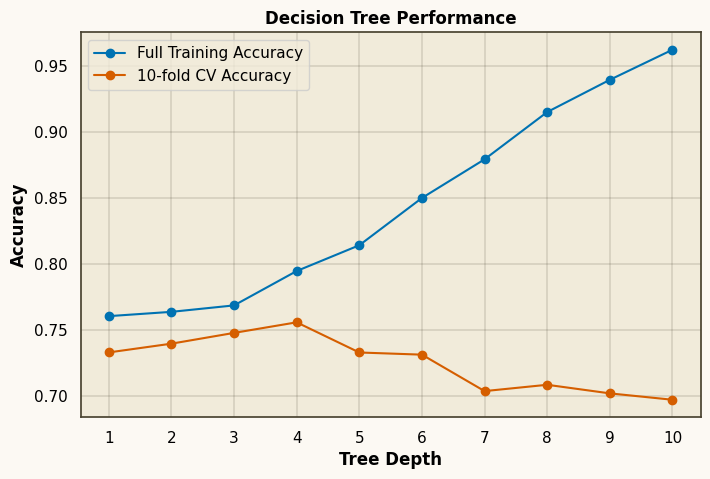

In [ ]:
# Store training and cross-validation accuracies
full_accuracy = []
cv_accuracy = []

# Evaluate tree performance for different depths
for depth in range(1,11):

    tree = DecisionTreeClassifier(max_depth=depth, random_state=10)

    # Train the model on the training set
    tree.fit(X_train, y_train)

    # Accuracy on training data
    full_accuracy.append(tree.score(X_train, y_train))

    # Cross-validation accuracy
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=10)
    cv_score = cross_val_score(tree, X_train, y_train, cv=cv)

    cv_accuracy.append(cv_score.mean())

# Plotting
max_depths = list(range(1,11))
plt.plot(max_depths, full_accuracy, marker="o", label= "Full Training Accuracy", color="#0072B2")
plt.plot(max_depths, cv_accuracy , marker="o", label= "10-fold CV Accuracy", color="#D55E00")
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Performance")
plt.xticks(max_depths)
plt.legend()
plt.show()


The highest training accuracy was achieved at larger tree depths, but training accuracy alone is not enough for selecting the best model because deeper trees may overfit the training data. The highest cross-validation accuracy was achieved at max_depth = 4. After this point, training accuracy continued to increase while cross-validation accuracy decreased, indicating overfitting. Therefore, a tree depth of 4 was selected as the best balance between model complexity and generalization performance.



# **Random Forest Model**
A Random Forest model was trained using different numbers of trees (n_estimators) from 1 to 20 while keeping the tree depth fixed at 4. For each setting, 10-fold cross-validation accuracy was calculated to evaluate model performance. The results were used to identify the number of trees that provided the best performance.

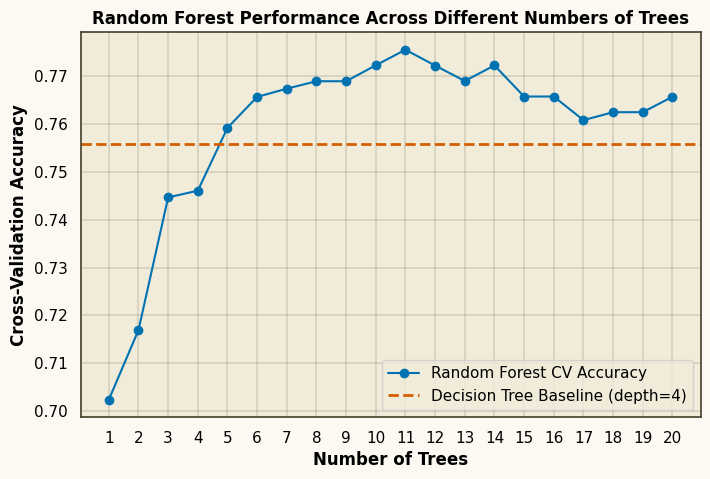

In [ ]:
# Store cross-validation accuracy for Random Forest
cv_accuracy_rf = []

# Evaluate Random Forest performance for 1 to 20 trees
for n in range(1, 21):
    rf = RandomForestClassifier(max_depth=4, n_estimators=n, random_state=10)

    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=10)
    cv_score = cross_val_score(rf, X_train, y_train, cv=cv)

    cv_accuracy_rf.append(cv_score.mean())

# Plot Random Forest CV accuracy
n_estimators_list = list(range(1, 21))

plt.plot(
    n_estimators_list,
    cv_accuracy_rf,
    marker="o",
    label="Random Forest CV Accuracy",
    color="#0072B2"
)

# Add Decision Tree baseline for comparison
plt.axhline(
    y=cv_accuracy[3],
    color="#D55E00",
    linestyle="--",
    linewidth=2,
    label="Decision Tree Baseline (depth=4)"
)

plt.xlabel("Number of Trees")
plt.ylabel("Cross-Validation Accuracy")
plt.title("Random Forest Performance Across Different Numbers of Trees")
plt.xticks(n_estimators_list)
plt.legend()
plt.show()

 A Random Forest with one tree behaves like a single randomized tree, but it is not identical to the Decision Tree model because Random Forest adds randomness through bootstrapping and feature selection. As the number of trees increases, the model becomes more stable and achieves higher cross-validation accuracy than the Decision Tree baseline.

 The Random Forest model achieved the highest cross-validation accuracy when n_estimators = 11. This indicates that using 11 trees provided the best performance among the tested values.

 After selecting the optimal number of trees, the max_depth parameter was tuned to identify the tree depth that provides the best cross-validation performance for the Random Forest model.

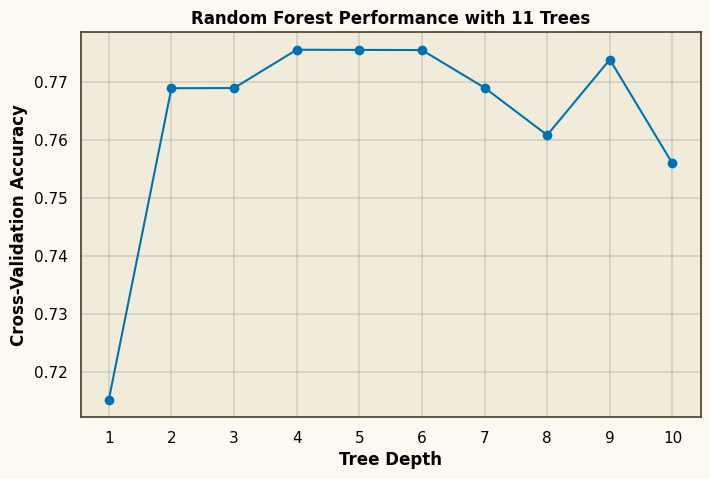

In [ ]:
# Store cross-validation accuracy for each tree depth
cv_accuracy_rf_depth = []

# Evaluate max_depth values from 1 to 10 using the best n_estimators value
for depth in range(1,11):
  rf_d = RandomForestClassifier(max_depth=depth, n_estimators=11, random_state=10)

  cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=10)
  cv_score = cross_val_score(rf_d, X_train , y_train, cv=cv)
  cv_accuracy_rf_depth.append(cv_score.mean())

# Plot Random Forest CV accuracy
max_depths = list(range(1, 11))

plt.plot(
    max_depths,
    cv_accuracy_rf_depth,
    marker="o",
    color="#0072B2"
)

plt.xlabel("Tree Depth")
plt.ylabel("Cross-Validation Accuracy")
plt.title("Random Forest Performance with 11 Trees")
plt.xticks(max_depths)
plt.show()


The highest cross-validation accuracy was achieved at tree depths 4, 5, and 6. Since all three depths produced similar performance, a depth of 4 was selected because it is the simplest model and is less likely to overfit the training data.



# **Final model training**

In [ ]:
final_model = RandomForestClassifier(
    n_estimators=11,
    max_depth=4,
    random_state=10
)

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.59      0.48      0.53        54

    accuracy                           0.70       154
   macro avg       0.67      0.65      0.66       154
weighted avg       0.69      0.70      0.69       154



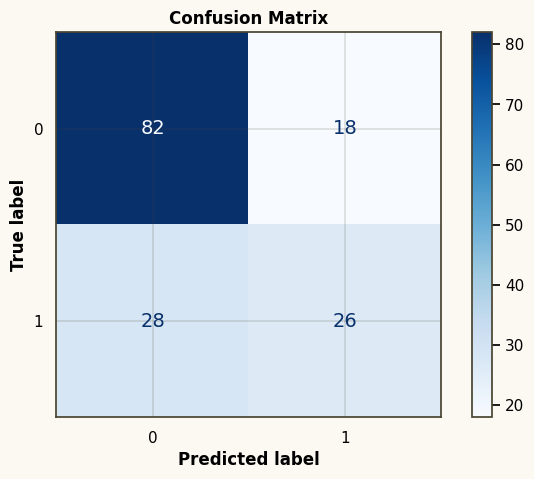

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.show()

The final Random Forest model achieved an overall test accuracy of 70%. The model performed better at identifying non-diabetic patients than diabetic patients. For the diabetes class, the recall score was lower, indicating that some diabetic cases were missed by the model. This may be influenced by the class imbalance present in the dataset. Overall, the model demonstrates moderate predictive performance while highlighting opportunities for improvement in detecting diabetic cases.

The confusion matrix shows that the model correctly identified 82 non-diabetic patients and 26 diabetic patients. However, 28 diabetic cases were incorrectly classified as non-diabetic, resulting in a relatively low recall for the diabetes class. This indicates that the model performs better at identifying non-diabetic patients than diabetic patients.

# **Dimensionality Reduction with PCA**

Principal Component Analysis (PCA) was applied to reduce the dimensionality of the dataset and visualize the data in a lower-dimensional space. This helps examine whether diabetic and non-diabetic patients show separation based on the principal components.


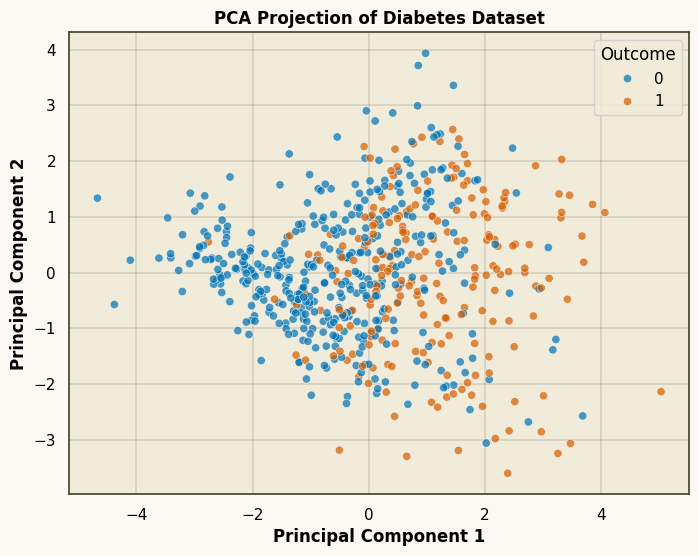

In [ ]:
# Apply PCA
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_train)

pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

pca_df['Outcome'] = y_train.reset_index(drop=True)

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Outcome',
    palette=['#0072B2', '#D55E00'],
    alpha=0.7
)

plt.title('PCA Projection of Diabetes Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Outcome')
plt.show()

The PCA projection shows some separation between diabetic and non-diabetic patients along the first principal component (PC1). Patients with diabetes tend to cluster more toward the positive side of PC1, while non-diabetic patients are more concentrated toward the left and center regions. However, there is still noticeable overlap between the two groups, indicating that the classes are not perfectly separable in a lower-dimensional space.

A PCA loading plot was created to show how the original features contribute to the first two principal components. Longer arrows indicate stronger contributions, while the direction of the arrows shows how features relate to each component.

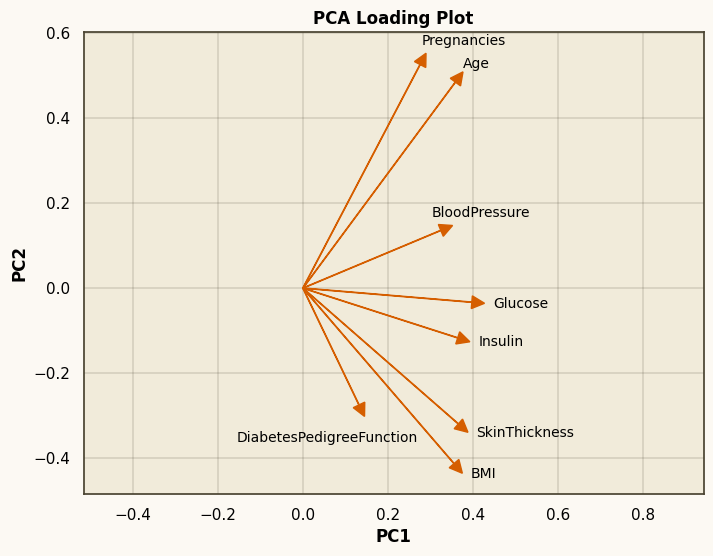

In [ ]:
# Get PCA loadings/rotation values
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=X.columns
)

plt.figure(figsize=(8, 6))

label_offsets = {
    'Pregnancies': (-0.01, 0.02),
    'Glucose': (0.02, -0.01),
    'BloodPressure': (-0.05, 0.02),
    'SkinThickness': (0.02, -0.01),
    'Insulin': (0.02, -0.01),
    'BMI': (0.02, -0.01),
    'DiabetesPedigreeFunction': (-0.3, -0.06),
    'Age': (0, 0.01)
}

# Draw arrows for each feature
for feature in loadings.index:

    x = loadings.loc[feature, 'PC1']
    y = loadings.loc[feature, 'PC2']

    plt.arrow(
        0, 0,
        x, y,
        head_width=0.03,
        head_length=0.03,
        color='#D55E00',
        length_includes_head=True
    )

    dx, dy = label_offsets.get(feature, (0, 0))

    plt.text(
        x + dx,
        y + dy,
        feature,
        fontsize=10
    )
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Loading Plot')
plt.grid(True)
plt.axis('equal')
plt.show()

The PCA loading plot suggests that variables such as Glucose, BMI, SkinThickness, Insulin, Age, and Pregnancies contribute positively to the first principal component (PC1). Since diabetic patients appear more concentrated on the positive side of PC1 in the PCA projection, these features may play an important role in distinguishing diabetic and non-diabetic patients.

Finally, the variance explained plot shows how much variability each principal component captures from the original dataset.

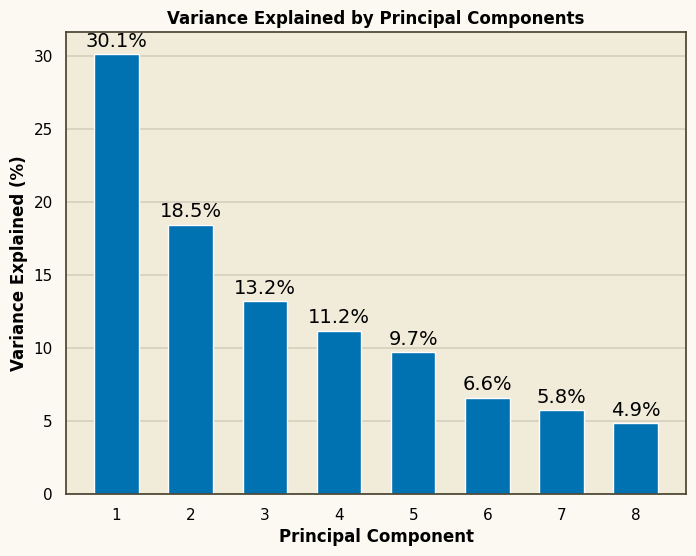

In [ ]:
# Fit PCA using all components
pca = PCA()
pca.fit(X_train)

explained_variance = pca.explained_variance_ratio_ *100

plt.figure(figsize=(8, 6))
plt.bar(
    range(1, len(explained_variance) + 1),
    explained_variance,
    color="#0072B2",
    width=0.6
)

# Remove vertical gridlines
plt.grid(axis='x', visible=False)

# Add percentage labels above bars
for i, v in enumerate(explained_variance):
    plt.text(
        i + 1,
        v + 0.5,
        f'{v:.1f}%',
        ha='center'
    )

plt.xlabel("Principal Component")
plt.ylabel("Variance Explained (%)")
plt.title("Variance Explained by Principal Components")
plt.xticks(range(1, len(explained_variance) + 1))
plt.show()

The first principal component (PC1) explains approximately 30% of the total variance, while the second principal component (PC2) explains about 19%. Together, the first two principal components capture nearly half of the variability in the dataset.

# **Discussion**

Random Forest achieved better generalization performance than a single Decision Tree, although the model still struggled to detect some diabetic patients due to class imbalance. PCA analysis showed partial separation between classes and highlighted important contributing variables such as Glucose, BMI, Age, and Pregnancies.